# Analisis Pengaruh Teknik Preprocessing terhadap Klasifikasi Ginjal Normal dan Batu Ginjal Menggunakan Fitur Gray Level Co-occurrence Matrix (GLCM) serta Perbandingan Algoritma Support Vector Machine (SVM), Random Forest, dan K-Nearest Neighbor (KNN)
## Percobaan 3 — Preprocessing: Grayscale + Resize + CLAHE + Sharpening (4 Preprocessing)
### Nama Anggota
- Muhammad Andika Azkiya : F1D02410076
- Gusti Ayu Marsha Widyaswari : F1D02410007
- Ahmad Yadan Ulya Munaji : F1D02410100
- Revano Januar Adiguna Prawira : F1D02410146

In [1]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns

## Import Library

### Fungsi
Cell ini mengimpor seluruh library yang diperlukan selama proses penelitian, mulai dari pengolahan citra digital, ekstraksi fitur tekstur menggunakan Gray Level Co-occurrence Matrix (GLCM), visualisasi data, hingga proses klasifikasi menggunakan algoritma Machine Learning.

Library yang digunakan meliputi:

- OpenCV (cv2) untuk pengolahan citra digital.
- NumPy untuk komputasi numerik dan manipulasi array.
- Pandas untuk pengelolaan data tabular.
- Matplotlib untuk visualisasi data.
- Scikit-image untuk pembentukan matriks GLCM dan ekstraksi fitur tekstur.
- Scikit-learn untuk pembagian data, normalisasi, pelatihan model, dan evaluasi klasifikasi.

### Analisis
Tahap import library merupakan langkah awal yang penting karena seluruh proses penelitian bergantung pada fungsi-fungsi yang tersedia dalam library tersebut. Pemilihan library yang tepat memungkinkan proses pengolahan data dilakukan secara lebih efisien, akurat, dan mudah direproduksi.

## Memuat Dataset dan Resize Citra

### Fungsi
Cell ini membaca seluruh citra ginjal dari dataset kemudian melakukan proses resize menjadi ukuran 256×256 piksel.

Selain itu, label kelas dan nama file citra juga disimpan untuk digunakan pada tahap ekstraksi fitur dan klasifikasi.

### Analisis
Ukuran citra yang berbeda dapat menyebabkan ketidakkonsistenan dalam proses ekstraksi fitur. Oleh karena itu dilakukan resize agar seluruh citra memiliki dimensi yang seragam.

Ukuran 256×256 piksel dipilih karena mampu mempertahankan informasi tekstur yang cukup baik sekaligus menjaga efisiensi komputasi selama proses penelitian.

In [2]:
def resize_image(image, target_size=(256, 256)):
    return cv.resize(image, target_size)

data = []
labels = []
file_name = []

dataset_path = 'Assets'

for sub_folder in sorted(os.listdir(dataset_path)):
    folder_path = os.path.join(dataset_path, sub_folder)
    if not os.path.isdir(folder_path):
        continue
    for filename in os.listdir(folder_path):
        img_path = os.path.join(folder_path, filename)
        img = cv.imread(img_path)
        if img is None:
            continue
        img = resize_image(img, (256, 256))
        img = img.astype(np.uint8)
        data.append(img)
        labels.append(sub_folder)
        file_name.append(filename)

data = np.array(data)
labels = np.array(labels)
print(f'Total data: {len(data)}')
print(f'Labels: {np.unique(labels)}')

Total data: 648
Labels: ['Normal' 'kidneyStone']


## Visualisasi Distribusi Dataset

### Fungsi
Cell ini menampilkan distribusi jumlah citra pada masing-masing kelas menggunakan diagram batang (*bar chart*). Visualisasi ini digunakan untuk mengetahui komposisi dataset yang akan digunakan pada proses ekstraksi fitur GLCM dan klasifikasi.

### Analisis
Berdasarkan grafik distribusi dataset, diperoleh:

- Kelas **Normal** sebanyak **356 citra**
- Kelas **Kidney Stone** sebanyak **292 citra**

Sehingga total dataset yang digunakan dalam penelitian ini berjumlah **648 citra**.

Pemilihan jumlah data yang lebih banyak dilakukan karena pada percobaan awal menggunakan dataset yang lebih kecil, yaitu sekitar **100 citra untuk masing-masing kelas**, seluruh model klasifikasi mampu mencapai akurasi mendekati atau bahkan mencapai **100%**. Kondisi tersebut menunjukkan bahwa dataset terlalu mudah dipelajari oleh model sehingga perbedaan performa antar metode preprocessing maupun algoritma klasifikasi menjadi sulit diamati.

Oleh karena itu, jumlah data diperbesar agar variasi karakteristik citra yang dipelajari model menjadi lebih beragam. Dengan semakin banyak data yang digunakan, tingkat kompleksitas klasifikasi juga meningkat karena model harus mengenali lebih banyak variasi bentuk, tekstur, pencahayaan, dan karakteristik citra pada masing-masing kelas.

Meskipun jumlah data kelas Normal dan Kidney Stone tidak sama persis, perbedaannya masih relatif kecil sehingga distribusi dataset tetap dapat dianggap cukup seimbang. Kondisi ini memungkinkan model memperoleh representasi yang baik dari kedua kelas tanpa menimbulkan bias yang signifikan terhadap salah satu kelas.

Penggunaan dataset yang lebih besar diharapkan dapat menghasilkan evaluasi yang lebih realistis dan mampu menunjukkan pengaruh teknik preprocessing terhadap performa klasifikasi. Dengan demikian, perbandingan antara Random Forest, Support Vector Machine (SVM), dan K-Nearest Neighbor (KNN) dapat dilakukan secara lebih objektif karena model diuji pada data yang lebih beragam dan menantang dibandingkan percobaan awal.

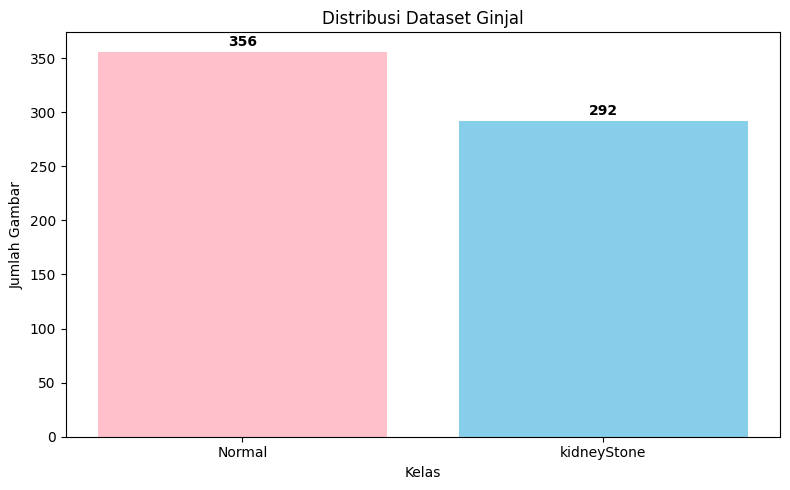

In [3]:
unique, counts = np.unique(labels, return_counts=True)
plt.figure(figsize=(8, 5))
plt.bar(unique, counts, color=['pink', 'skyblue'])
plt.xlabel('Kelas')
plt.ylabel('Jumlah Gambar')
plt.title('Distribusi Dataset Ginjal')
for i, (u, c) in enumerate(zip(unique, counts)):
    plt.text(i, c + 5, str(c), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Visualisasi Sampel Citra Dataset

### Fungsi
Cell ini menampilkan beberapa contoh citra dari masing-masing kelas yang terdapat dalam dataset.

### Analisis
Visualisasi sampel citra digunakan untuk melakukan pemeriksaan awal terhadap kualitas data dan memastikan proses pembacaan citra berjalan dengan baik.

Melalui tahap ini dapat diamati karakteristik visual dari citra ginjal normal dan batu ginjal sebelum dilakukan proses preprocessing lebih lanjut.

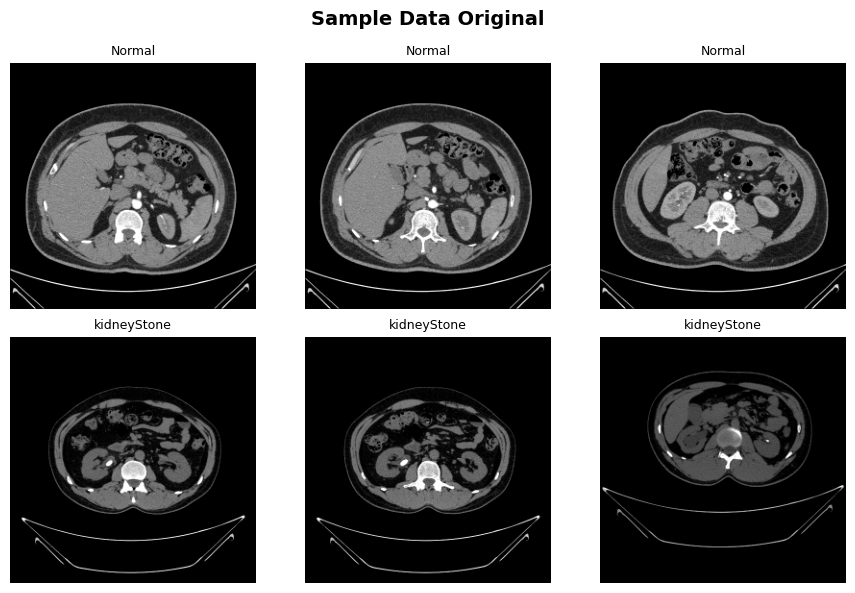

In [4]:
def show_sample_images(images, labels, class_names, title='Sample Images', n=3):
    fig, axes = plt.subplots(len(class_names), n, figsize=(n*3, len(class_names)*3))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    for i, cls in enumerate(class_names):
        idx = np.where(labels == cls)[0]
        for j in range(min(n, len(idx))):
            img = images[idx[j]]
            if len(img.shape) == 3:
                axes[i][j].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
            else:
                axes[i][j].imshow(img, cmap='gray')
            axes[i][j].set_title(f'{cls}', fontsize=9)
            axes[i][j].axis('off')
    plt.tight_layout()
    plt.show()

class_names = sorted(np.unique(labels))
show_sample_images(data, labels, class_names, 'Sample Data Original')

## Konversi Citra ke Grayscale

### Fungsi
Cell ini mengubah seluruh citra berwarna menjadi citra grayscale menggunakan fungsi konversi warna pada OpenCV.

### Analisis
GLCM bekerja berdasarkan hubungan tingkat keabuan antar piksel sehingga informasi warna tidak diperlukan.

Konversi grayscale memberikan beberapa keuntungan:

- Mengurangi kompleksitas data.
- Mempercepat proses komputasi.
- Menghilangkan informasi warna yang tidak relevan.
- Memfokuskan analisis pada karakteristik tekstur citra.

Output tahap ini berupa citra grayscale yang siap diproses lebih lanjut.

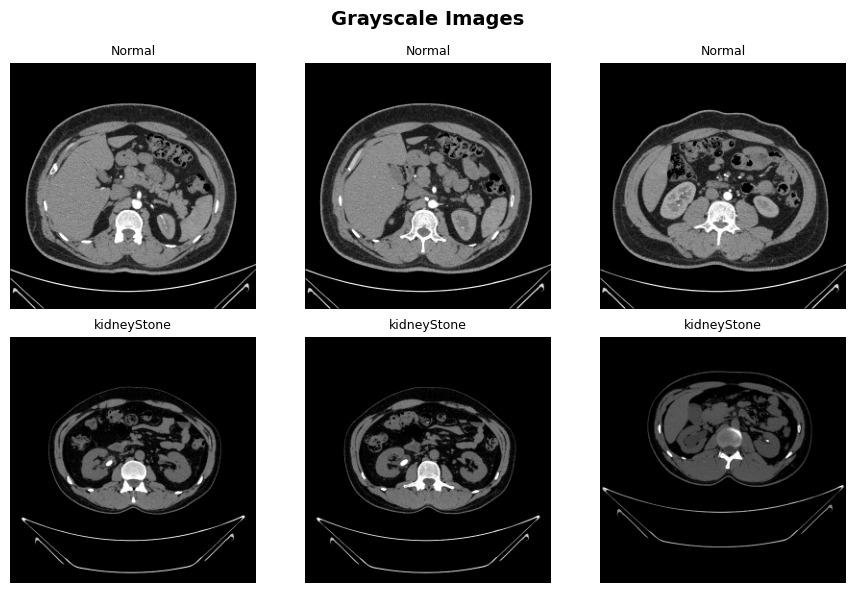

In [5]:
img_grey = []
for img in data:
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    img_grey.append(gray)
img_grey = np.array(img_grey)

show_sample_images(img_grey, labels, class_names, 'Grayscale Images')

## Penerapan Contrast Limited Adaptive Histogram Equalization (CLAHE)

### Fungsi
Cell ini menerapkan metode Contrast Limited Adaptive Histogram Equalization (CLAHE) pada citra grayscale.

CLAHE merupakan pengembangan dari Histogram Equalization yang bekerja secara lokal pada setiap wilayah kecil citra (tile) sehingga peningkatan kontras dapat dilakukan secara lebih adaptif.

### Analisis
Pada citra medis sering ditemukan perbedaan pencahayaan dan kontras yang tidak merata. CLAHE digunakan untuk meningkatkan kualitas citra tanpa menyebabkan amplifikasi noise yang berlebihan.

Keunggulan CLAHE antara lain:

- Meningkatkan kontras lokal citra.
- Memperjelas detail tekstur.
- Mempertegas batas objek.
- Mengurangi risiko over-enhancement dibanding Histogram Equalization biasa.
- Cocok digunakan pada citra medis.

Dengan kontras yang lebih baik, pola tekstur ginjal menjadi lebih mudah dikenali sehingga fitur GLCM yang dihasilkan menjadi lebih representatif.

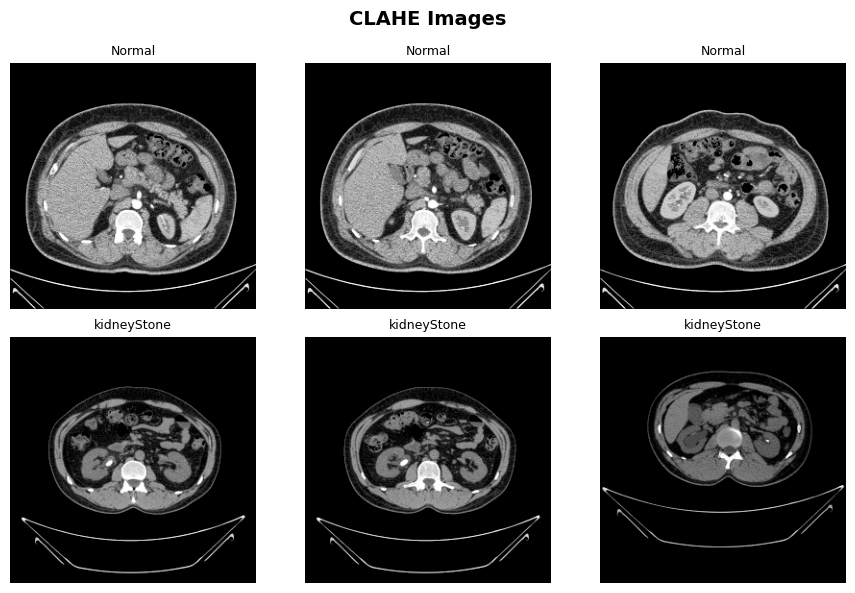

In [6]:
def clahe_manual(img, clip_limit=2.0):
    hist = np.zeros(256)
    for pixel in img.flatten():
        hist[pixel] += 1
    clip_value = clip_limit * img.size / 256
    excess = 0
    for i in range(256):
        if hist[i] > clip_value:
            excess += hist[i] - clip_value
            hist[i] = clip_value
    hist += excess / 256
    cdf = np.cumsum(hist)
    cdf = (cdf - cdf.min()) / (cdf.max() - cdf.min())
    lut = np.round(cdf * 255).astype(np.uint8)
    return lut[img]
img_clahe = []
for img in img_grey:
    img_clahe.append(clahe_manual(img))
img_clahe = np.array(img_clahe)
show_sample_images(
    img_clahe,
    labels,
    class_names,
    'CLAHE Images'
)

## Penerapan Sharpening

### Fungsi
Cell ini menerapkan teknik Sharpening pada citra hasil CLAHE.

Sharpening bertujuan meningkatkan ketajaman citra dengan memperjelas tepi dan detail objek melalui proses penekanan perbedaan intensitas antar piksel.

### Analisis
Setelah peningkatan kontras menggunakan CLAHE, proses Sharpening dilakukan untuk mempertegas struktur tekstur yang terdapat pada citra ginjal.

Manfaat penggunaan Sharpening meliputi:

- Memperjelas detail tekstur.
- Mempertegas batas objek.
- Meningkatkan kualitas fitur tekstur yang diekstraksi.
- Membantu model membedakan pola ginjal normal dan batu ginjal.

Kombinasi CLAHE dan Sharpening diharapkan menghasilkan citra dengan kualitas visual yang lebih baik sehingga performa klasifikasi dapat meningkat.

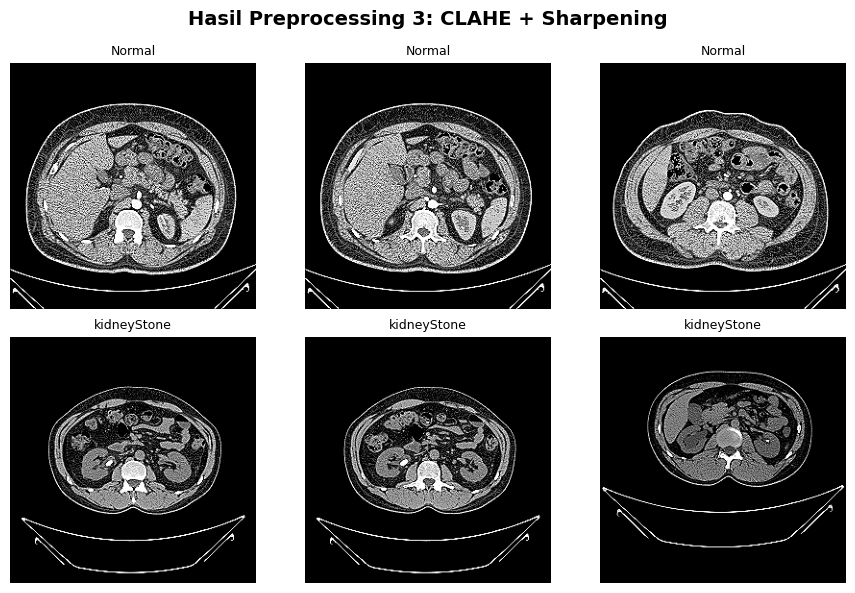

In [7]:
def sharpen_image(image):
    kernel = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])
    sharpened = cv.filter2D(image, -1, kernel)
    return np.clip(sharpened, 0, 255).astype(np.uint8)

dataPreprocessed = []
for img in img_clahe:
    sharpened = sharpen_image(img)
    dataPreprocessed.append(sharpened)
dataPreprocessed = np.array(dataPreprocessed)

show_sample_images(dataPreprocessed, labels, class_names, 'Hasil Preprocessing 3: CLAHE + Sharpening')

In [8]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. Should be 0, 45, 90, or 135.")
    glcm_matrix = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm_matrix

def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

## Definisi Fungsi GLCM dan Fitur Tekstur

### Fungsi
Cell ini mendefinisikan fungsi pembentukan matriks Gray Level Co-occurrence Matrix (GLCM) dan perhitungan fitur tekstur yang akan digunakan dalam proses klasifikasi.

Fitur yang diekstraksi meliputi:

- Contrast
- Dissimilarity
- Homogeneity
- Energy
- Correlation
- ASM

### Analisis
GLCM merupakan metode statistik orde kedua yang digunakan untuk menggambarkan hubungan spasial antar piksel pada citra.

Fitur-fitur yang dihasilkan mampu merepresentasikan karakteristik tekstur citra sehingga dapat digunakan sebagai masukan bagi algoritma Machine Learning.

## Pembentukan Matriks GLCM pada Berbagai Sudut

### Fungsi
Cell ini membentuk matriks GLCM pada empat orientasi sudut:

- 0°
- 45°
- 90°
- 135°

### Analisis
Penggunaan beberapa orientasi sudut bertujuan memperoleh informasi tekstur yang lebih lengkap karena hubungan antar piksel dapat berbeda pada setiap arah.

Pendekatan ini membantu menghasilkan representasi tekstur yang lebih baik sehingga meningkatkan kemampuan model dalam membedakan kedua kelas citra.

In [9]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)
print(f'GLCM computed for {len(Derajat0)} images')

GLCM computed for 648 images


## Ekstraksi Fitur Tekstur GLCM

### Fungsi
Cell ini menghitung berbagai fitur tekstur dari matriks GLCM yang telah dibentuk sebelumnya.

### Analisis
Tahap ekstraksi fitur bertujuan mengubah informasi visual citra menjadi data numerik yang dapat diproses oleh algoritma Machine Learning.

Fitur yang dihasilkan diharapkan mampu menangkap perbedaan karakteristik tekstur antara ginjal normal dan ginjal batu.

In [10]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 = [], [], [], []
ASM0, ASM45, ASM90, ASM135 = [], [], [], []
energy0, energy45, energy90, energy135 = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    # Correlation
    correlation0.append(correlation(Derajat0[i]))
    correlation45.append(correlation(Derajat45[i]))
    correlation90.append(correlation(Derajat90[i]))
    correlation135.append(correlation(Derajat135[i]))
    # Contrast
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))
    # Dissimilarity
    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))
    # Homogeneity
    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))
    # Entropy
    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))
    # ASM
    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))
    # Energy
    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

print('Feature extraction completed!')

Feature extraction completed!


## Pembentukan Dataset Fitur GLCM

### Fungsi
Cell ini menyusun seluruh fitur hasil ekstraksi Gray Level Co-occurrence Matrix (GLCM) ke dalam sebuah DataFrame menggunakan library Pandas.

Setiap baris merepresentasikan satu citra ginjal, sedangkan setiap kolom merepresentasikan fitur tekstur yang diperoleh dari proses ekstraksi GLCM pada berbagai orientasi sudut.

Dataset yang terbentuk terdiri dari:

- Filename
- Label
- Contrast (0°, 45°, 90°, 135°)
- Homogeneity (0°, 45°, 90°, 135°)
- Dissimilarity (0°, 45°, 90°, 135°)
- Entropy (0°, 45°, 90°, 135°)
- ASM (0°, 45°, 90°, 135°)
- Energy (0°, 45°, 90°, 135°)
- Correlation (0°, 45°, 90°, 135°)

### Analisis

Hasil ekstraksi menghasilkan **648 data citra** yang terdiri dari kelas Normal dan Kidney Stone dengan total **28 fitur tekstur GLCM**.

Berbeda dengan preprocessing sebelumnya, pada percobaan ini citra telah melalui tahapan **CLAHE (Contrast Limited Adaptive Histogram Equalization)** dan **Sharpening** sebelum proses ekstraksi fitur dilakukan.

CLAHE meningkatkan kontras lokal pada citra sehingga detail tekstur menjadi lebih jelas, sedangkan Sharpening mempertegas batas objek dan perbedaan intensitas antar piksel. Kombinasi kedua teknik tersebut menyebabkan variasi nilai intensitas piksel menjadi lebih besar dibandingkan preprocessing sebelumnya.

Hal ini terlihat pada nilai fitur Contrast yang mengalami peningkatan cukup signifikan. Nilai Contrast yang tinggi menunjukkan bahwa citra memiliki perbedaan intensitas yang lebih jelas antar piksel yang berdekatan. Kondisi tersebut mengindikasikan bahwa proses CLAHE dan Sharpening berhasil memperkuat karakteristik tekstur yang terdapat pada citra ginjal.

Selain itu, nilai Correlation yang berada pada kisaran tinggi menunjukkan bahwa hubungan spasial antar piksel masih tetap terjaga meskipun citra mengalami peningkatan kontras dan ketajaman.

Perbedaan distribusi nilai fitur antara kelas Normal dan Kidney Stone menunjukkan bahwa metode GLCM berhasil menangkap perubahan tekstur yang muncul akibat keberadaan batu ginjal. Informasi inilah yang nantinya digunakan oleh algoritma klasifikasi untuk membedakan kedua kelas secara otomatis.

Output dari tahap ini berupa dataset fitur tekstur yang telah terstruktur dan siap digunakan pada proses seleksi fitur, normalisasi, dan klasifikasi.

In [11]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan3.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan3.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,1.jpg,Normal,4588.847503,5496.776286,5627.459452,5391.850519,0.529849,0.517739,0.516240,0.519463,...,0.245864,0.246983,0.502983,0.495976,0.495846,0.496974,0.690814,0.630332,0.620843,0.637388
1,10.jpg,Normal,4526.546814,5341.151834,5376.157813,5187.210888,0.530128,0.518454,0.519198,0.520422,...,0.249771,0.249371,0.505251,0.498291,0.499771,0.499370,0.690989,0.636060,0.632996,0.646550
2,100.jpg,Normal,3790.323912,4783.793126,4743.531725,4726.096855,0.564812,0.551757,0.551467,0.552519,...,0.285238,0.284967,0.541769,0.533190,0.534077,0.533823,0.722453,0.650413,0.652654,0.654630
3,11.jpg,Normal,4571.143336,5298.618562,5336.946921,5188.695609,0.529935,0.519303,0.519968,0.521033,...,0.249824,0.249391,0.505248,0.498255,0.499824,0.499390,0.688135,0.639177,0.635893,0.646662
4,12.jpg,Normal,4549.779213,5320.510158,5293.400613,5169.312957,0.530147,0.518524,0.521288,0.520963,...,0.250679,0.249859,0.505291,0.497919,0.500678,0.499859,0.689632,0.637734,0.638911,0.648028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
643,Stone- (515).jpg,kidneyStone,2929.421982,3929.276278,3759.879519,3882.261899,0.555973,0.542244,0.542086,0.541502,...,0.278507,0.278580,0.536337,0.527786,0.527738,0.527807,0.738361,0.649752,0.664216,0.653942
644,Stone- (516).jpg,kidneyStone,2957.426455,3928.818454,3797.188036,3912.759123,0.554734,0.542026,0.541091,0.541895,...,0.277696,0.278760,0.535647,0.528183,0.526969,0.527977,0.735930,0.649895,0.660983,0.651326
645,Stone- (517).jpg,kidneyStone,2979.708395,3947.843799,3833.783931,3993.836140,0.555983,0.542964,0.540581,0.542517,...,0.277497,0.278851,0.535983,0.528396,0.526780,0.528063,0.735506,0.650262,0.659721,0.646187
646,Stone- (518).jpg,kidneyStone,2998.419240,3953.594064,3847.455453,4050.245598,0.556363,0.543015,0.542234,0.541669,...,0.277702,0.277640,0.535497,0.527668,0.526974,0.526915,0.734915,0.651152,0.659869,0.642623


## Seleksi Fitur Menggunakan Correlation Matrix

### Fungsi
Cell ini melakukan proses seleksi fitur menggunakan metode Correlation Matrix untuk mengidentifikasi dan menghapus fitur-fitur yang memiliki korelasi sangat tinggi.

Fitur dengan nilai korelasi di atas ambang batas yang ditentukan dianggap memiliki informasi yang serupa sehingga salah satunya dapat dihilangkan tanpa kehilangan informasi yang signifikan.

### Hasil Seleksi Fitur

Berdasarkan proses seleksi diperoleh:

- Jumlah fitur sebelum seleksi : **28 fitur**
- Jumlah fitur setelah seleksi : **6 fitur**
- Jumlah fitur yang dihapus : **22 fitur**

Fitur yang terpilih adalah:

- Contrast0
- Contrast90
- Homogeneity0
- Correlation0
- Correlation45
- Correlation90

### Alasan Penggunaan Correlation Matrix

Pada hasil ekstraksi GLCM, setiap fitur dihitung pada beberapa orientasi sudut sehingga banyak fitur yang memiliki pola nilai yang sangat mirip.

Kondisi ini menyebabkan beberapa fitur membawa informasi yang hampir sama sehingga dapat menimbulkan redundansi data apabila seluruh fitur digunakan secara bersamaan.

Oleh karena itu dilakukan seleksi fitur untuk mempertahankan fitur yang paling representatif dan menghilangkan fitur yang memiliki informasi berulang.

### Analisis Hasil

Hasil seleksi menunjukkan bahwa hanya **6 fitur** yang mampu mewakili keseluruhan informasi tekstur yang terdapat pada dataset. Hal ini menunjukkan bahwa sebagian besar fitur GLCM memiliki hubungan yang sangat kuat satu sama lain setelah citra diproses menggunakan CLAHE dan Sharpening.

Fenomena ini terjadi karena peningkatan kontras dan ketajaman citra membuat pola tekstur menjadi lebih jelas dan lebih konsisten pada berbagai orientasi sudut. Akibatnya banyak fitur menghasilkan informasi yang serupa sehingga korelasi antar fitur meningkat.

Menariknya, fitur yang bertahan didominasi oleh:

- Contrast
- Homogeneity
- Correlation

Hal ini mengindikasikan bahwa perbedaan utama antara ginjal normal dan ginjal batu pada preprocessing ini lebih banyak ditentukan oleh:

1. Tingkat variasi intensitas piksel (Contrast).
2. Tingkat keseragaman tekstur (Homogeneity).
3. Hubungan spasial antar piksel (Correlation).

Sementara fitur lainnya seperti Dissimilarity, Entropy, ASM, dan Energy memiliki korelasi yang sangat tinggi dengan fitur yang terpilih sehingga tidak memberikan informasi tambahan yang signifikan.

Pengurangan fitur dari 28 menjadi 6 fitur menghasilkan dataset yang lebih ringkas, mengurangi kompleksitas model, mempercepat proses pelatihan, dan berpotensi meningkatkan kemampuan generalisasi model tanpa kehilangan informasi penting yang dibutuhkan untuk proses klasifikasi.

Fitur sebelum seleksi: 28
Fitur setelah seleksi: 6
Fitur terpilih: ['Contrast0', 'Contrast90', 'Homogeneity0', 'Correlation0', 'Correlation45', 'Correlation90']


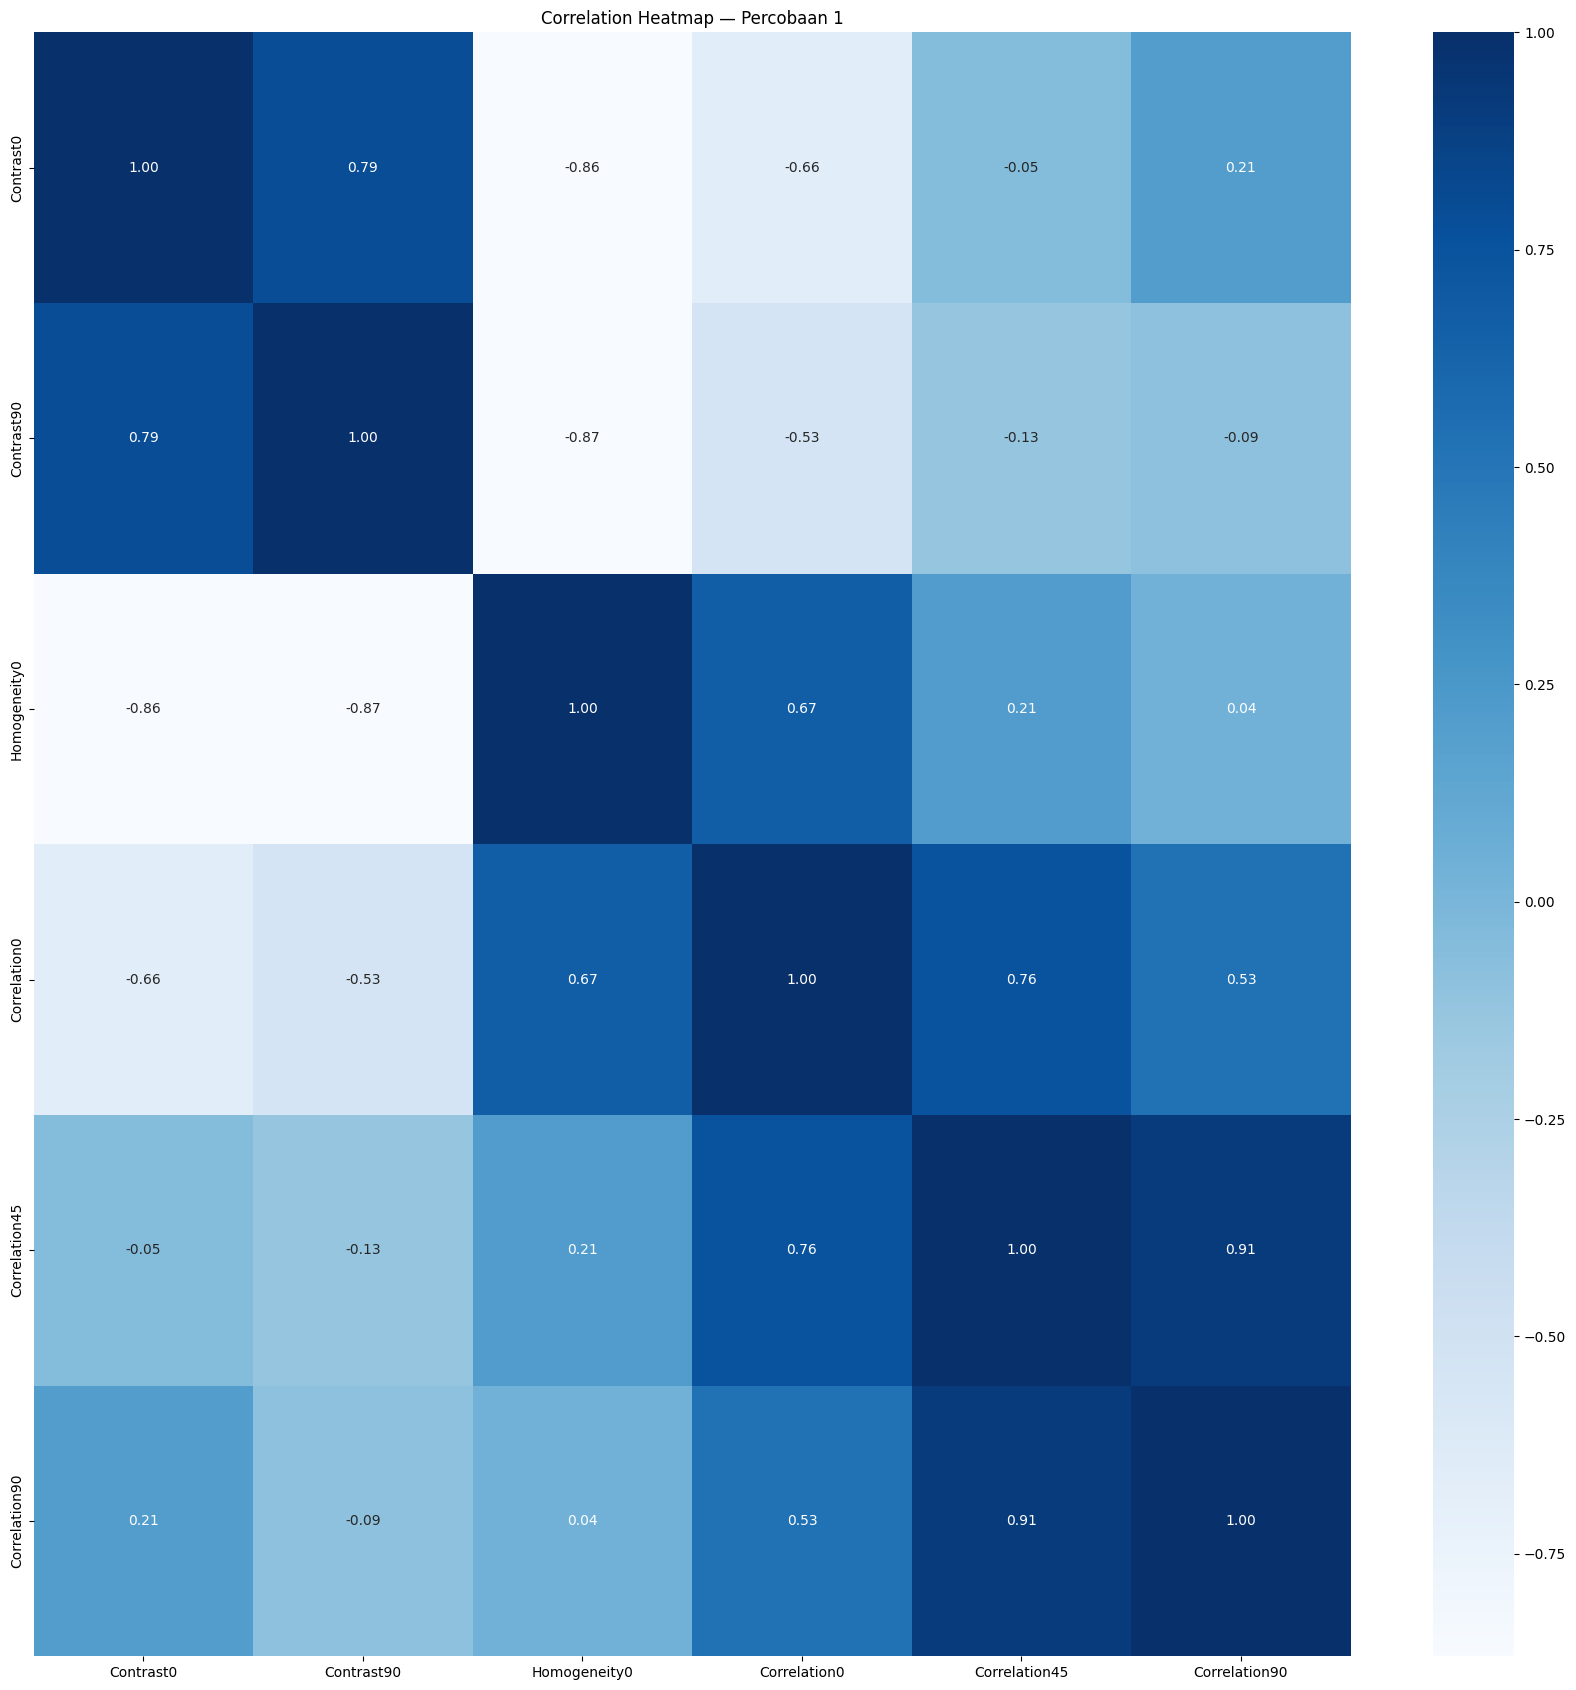

In [12]:
correlation_matrix = hasilEkstrak.drop(columns=['Label','Filename']).corr()

threshold = 0.95
columns = np.full((correlation_matrix.shape[0],), True, dtype=bool)
for i in range(correlation_matrix.shape[0]):
    for j in range(i+1, correlation_matrix.shape[0]):
        if correlation_matrix.iloc[i,j] >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f'Fitur sebelum seleksi: {len(hasilEkstrak.columns) - 2}')
print(f'Fitur setelah seleksi: {len(select)}')
print(f'Fitur terpilih: {list(select)}')

plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap — Percobaan 1')
plt.tight_layout()
plt.show()

## Pembagian Data Training dan Testing

### Fungsi
Cell ini membagi dataset fitur hasil seleksi menjadi data training dan data testing menggunakan fungsi `train_test_split()` dari library Scikit-Learn.

Pembagian data dilakukan secara acak untuk memastikan bahwa data training dan data testing memiliki distribusi yang representatif terhadap keseluruhan dataset.

### Hasil Pembagian Data

Berdasarkan proses pembagian data diperoleh:

- Data Training : **388 data**
- Data Testing : **260 data**
- Total Data : **648 data**

Setelah proses seleksi fitur, jumlah fitur yang digunakan pada tahap klasifikasi adalah sebanyak **6 fitur**, yaitu:

- Contrast0
- Contrast90
- Homogeneity0
- Correlation0
- Correlation45
- Correlation90

Sehingga ukuran dataset yang dihasilkan adalah:

- Training set : **(388, 6)**
- Testing set : **(260, 6)**

### Analisis

Data training digunakan untuk melatih model klasifikasi agar dapat mempelajari hubungan antara fitur tekstur GLCM dan kelas citra ginjal. Sementara itu, data testing digunakan untuk mengevaluasi kemampuan model dalam melakukan prediksi terhadap data yang tidak digunakan selama proses pelatihan.

Pada preprocessing ketiga, proses seleksi fitur berhasil mengurangi jumlah fitur dari 28 fitur menjadi hanya 6 fitur. Hal ini menunjukkan bahwa sebagian besar fitur memiliki korelasi yang sangat tinggi sehingga informasi yang dibawanya dapat diwakili oleh fitur lain.

Menariknya, fitur yang tersisa didominasi oleh Contrast, Homogeneity, dan Correlation. Kondisi ini menunjukkan bahwa setelah penerapan CLAHE dan Sharpening, informasi tekstur yang paling berpengaruh dalam membedakan ginjal normal dan batu ginjal lebih banyak berkaitan dengan:

- Tingkat variasi intensitas piksel (Contrast).
- Tingkat keseragaman tekstur (Homogeneity).
- Hubungan spasial antar piksel (Correlation).

Dengan hanya menggunakan 6 fitur terpilih, kompleksitas data menjadi lebih rendah dibandingkan preprocessing sebelumnya. Hal ini berpotensi mempercepat proses pelatihan model sekaligus mengurangi risiko overfitting tanpa menghilangkan informasi penting yang dibutuhkan untuk proses klasifikasi.

Selain itu, penggunaan jumlah fitur yang lebih sedikit juga menunjukkan bahwa kombinasi CLAHE dan Sharpening mampu menghasilkan fitur-fitur yang lebih representatif sehingga karakteristik tekstur utama citra dapat direpresentasikan oleh sejumlah kecil fitur yang memiliki daya diskriminasi tinggi.

Tahap pembagian data ini sangat penting karena memastikan bahwa performa model dievaluasi menggunakan data yang belum pernah dilihat sebelumnya, sehingga hasil evaluasi yang diperoleh dapat menggambarkan kemampuan generalisasi model secara lebih objektif.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.4, random_state=42)
print(f'Training set: {X_train.shape}')
print(f'Testing set: {X_test.shape}')

Training set: (388, 6)
Testing set: (260, 6)


In [14]:
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

## Normalisasi Data Fitur

### Fungsi
Cell ini melakukan normalisasi data menggunakan metode **Z-Score Standardization** atau **Standard Scaling**.

Normalisasi dilakukan dengan rumus:

\[
Z = \frac{x-\mu}{\sigma}
\]

dengan:

- \(x\) = nilai fitur
- \(\mu\) = rata-rata fitur pada data training
- \(\sigma\) = standar deviasi fitur pada data training

Pada proses ini, nilai rata-rata dan standar deviasi dihitung dari data training, kemudian digunakan untuk menormalisasi data training maupun data testing.

### Alasan Dilakukan Normalisasi

Fitur-fitur hasil ekstraksi GLCM memiliki rentang nilai yang berbeda-beda.

Sebagai contoh:

- Contrast dapat memiliki nilai hingga ribuan.
- Correlation umumnya berada pada rentang 0 hingga 1.
- Homogeneity biasanya memiliki nilai sekitar 0,4 hingga 0,8.

Perbedaan skala tersebut dapat menyebabkan fitur dengan nilai yang lebih besar mendominasi proses pembelajaran model.

Oleh karena itu dilakukan normalisasi agar seluruh fitur berada pada skala yang sebanding.

### Analisis

Setelah proses normalisasi, setiap fitur memiliki:

- Rata-rata (mean) mendekati 0.
- Standar deviasi (standard deviation) mendekati 1.

Proses ini membuat seluruh fitur memiliki kontribusi yang lebih seimbang selama proses klasifikasi.

Normalisasi menjadi sangat penting terutama pada algoritma:

- Support Vector Machine (SVM)
- K-Nearest Neighbor (KNN)

karena kedua algoritma tersebut menggunakan perhitungan jarak atau posisi data dalam ruang fitur. Apabila terdapat fitur dengan rentang nilai yang jauh lebih besar dibandingkan fitur lainnya, maka fitur tersebut dapat mendominasi proses klasifikasi dan menyebabkan hasil prediksi menjadi kurang optimal.

Pada penelitian ini, nilai rata-rata dan standar deviasi dihitung dari data training kemudian digunakan untuk menormalisasi data training dan data testing. Pendekatan ini dilakukan untuk menghindari terjadinya *data leakage*, yaitu kondisi ketika informasi dari data testing ikut digunakan selama proses pelatihan model.

Dengan demikian, proses evaluasi model dapat dilakukan secara lebih objektif dan mencerminkan kemampuan model dalam menghadapi data baru yang belum pernah dilihat sebelumnya.

In [15]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=100, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

## Inisialisasi Model Klasifikasi dan Fungsi Evaluasi

### Fungsi

Cell ini mendefinisikan fungsi evaluasi serta menginisialisasi tiga algoritma klasifikasi yang akan digunakan dalam penelitian, yaitu:

1. Random Forest (RF)
2. Support Vector Machine (SVM)
3. K-Nearest Neighbor (KNN)

Selain itu, dibuat fungsi `generateClassificationReport()` untuk menampilkan hasil evaluasi model berupa:

- Precision
- Recall
- F1-Score
- Accuracy

Hasil evaluasi tersebut digunakan untuk membandingkan performa masing-masing algoritma dalam mengklasifikasikan citra ginjal normal dan citra batu ginjal.

### Alasan Pemilihan Algoritma

Ketiga algoritma dipilih karena memiliki pendekatan klasifikasi yang berbeda sehingga dapat memberikan perbandingan performa yang lebih komprehensif terhadap fitur tekstur GLCM yang digunakan.

- Random Forest mewakili metode berbasis ensemble learning.
- SVM mewakili metode berbasis hyperplane.
- KNN mewakili metode berbasis kedekatan jarak antar data.

Dengan menggunakan ketiga algoritma tersebut, dapat diketahui algoritma mana yang paling efektif dalam mengenali pola tekstur citra ginjal.

### Parameter Model

#### Random Forest

```python
RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
```

Parameter `n_estimators=100` menunjukkan bahwa model membangun 100 pohon keputusan (*decision tree*) yang kemudian digabungkan melalui mekanisme voting untuk menghasilkan keputusan akhir.

Jumlah 100 pohon dipilih karena secara umum mampu memberikan keseimbangan antara akurasi dan waktu komputasi. Jumlah pohon yang terlalu sedikit dapat menyebabkan model kurang stabil, sedangkan jumlah yang terlalu banyak dapat meningkatkan waktu pelatihan tanpa peningkatan performa yang signifikan.

Parameter `random_state=42` digunakan untuk memastikan proses pembentukan model dapat direproduksi kembali pada percobaan berikutnya. Dengan nilai random state yang tetap, hasil eksperimen akan tetap konsisten setiap kali kode dijalankan.

#### Support Vector Machine (SVM)

```python
SVC(
    kernel='rbf',
    random_state=42
)
```

Kernel `rbf` (*Radial Basis Function*) dipilih karena mampu menangani hubungan non-linear antar fitur. Pada data tekstur GLCM, batas pemisah antara kelas Normal dan Kidney Stone belum tentu berbentuk linear sehingga kernel RBF sering memberikan performa yang lebih baik dibandingkan kernel linear.

Parameter `random_state=42` digunakan untuk menjaga konsistensi hasil eksperimen.

#### K-Nearest Neighbor (KNN)

```python
KNeighborsClassifier(
    n_neighbors=5
)
```

Parameter `n_neighbors=5` menunjukkan bahwa proses klasifikasi dilakukan berdasarkan lima tetangga terdekat dari suatu data.

Nilai K = 5 dipilih karena merupakan nilai yang umum digunakan dan mampu memberikan keseimbangan antara sensitivitas terhadap noise dan kemampuan generalisasi model. Nilai K yang terlalu kecil dapat menyebabkan model terlalu sensitif terhadap data tertentu, sedangkan nilai K yang terlalu besar dapat menyebabkan batas antar kelas menjadi kurang jelas.

### Analisis

Tahap ini merupakan langkah awal sebelum proses pelatihan model dilakukan. Parameter yang digunakan pada masing-masing algoritma dipilih berdasarkan konfigurasi yang umum digunakan dalam penelitian klasifikasi serta mampu memberikan performa yang stabil tanpa memerlukan proses optimasi parameter yang kompleks.

Dengan menggunakan konfigurasi yang sama pada seluruh percobaan preprocessing, perbedaan performa yang diperoleh nantinya lebih mencerminkan pengaruh teknik preprocessing dan kualitas fitur yang dihasilkan dibandingkan pengaruh perubahan parameter model.

Oleh karena itu, hasil evaluasi yang diperoleh dapat digunakan sebagai dasar yang lebih objektif untuk membandingkan performa Random Forest, Support Vector Machine (SVM), dan K-Nearest Neighbor (KNN) dalam mengklasifikasikan citra ginjal normal dan citra batu ginjal.

## Pelatihan dan Pengujian Model Random Forest

### Fungsi

Cell ini digunakan untuk melatih model Random Forest menggunakan data training yang telah melalui proses preprocessing, ekstraksi fitur GLCM, seleksi fitur, dan normalisasi.

Setelah model selesai dilatih, dilakukan proses prediksi terhadap data training dan data testing. Hasil prediksi kemudian dievaluasi menggunakan metrik:

- Precision
- Recall
- F1-Score
- Accuracy

Tujuan evaluasi ini adalah untuk mengukur kemampuan model dalam membedakan citra ginjal Normal dan Kidney Stone berdasarkan fitur tekstur yang telah diekstraksi.

### Hasil Pengujian

#### Data Training

Berdasarkan hasil evaluasi pada data training diperoleh:

| Metrik | Nilai |
|---------|---------|
| Accuracy | 100% |
| Precision | 100% |
| Recall | 100% |
| F1-Score | 100% |

Jumlah data training yang digunakan sebanyak **388 data**, terdiri dari:

- 194 citra Normal
- 194 citra Kidney Stone

#### Data Testing

Berdasarkan hasil evaluasi pada data testing diperoleh:

| Metrik | Nilai |
|---------|---------|
| Accuracy | 100% |
| Precision | 100% |
| Recall | 100% |
| F1-Score | 100% |

Jumlah data testing yang digunakan sebanyak **260 data**, terdiri dari:

- 162 citra Normal
- 98 citra Kidney Stone

### Analisis

Hasil pengujian menunjukkan bahwa model Random Forest berhasil mengklasifikasikan seluruh data training dan data testing dengan benar sehingga memperoleh nilai Accuracy, Precision, Recall, dan F1-Score sebesar 100%.

Tidak ditemukan kesalahan klasifikasi pada kedua kelas, baik Normal maupun Kidney Stone. Hal ini menunjukkan bahwa fitur tekstur yang digunakan memiliki kemampuan yang sangat baik dalam membedakan karakteristik kedua kelas citra.

Berbeda dengan preprocessing sebelumnya, pada preprocessing ketiga citra telah melalui tahapan CLAHE (*Contrast Limited Adaptive Histogram Equalization*) dan Sharpening sebelum dilakukan ekstraksi fitur. CLAHE meningkatkan kontras lokal pada citra sehingga detail tekstur menjadi lebih jelas, sedangkan Sharpening mempertegas batas objek dan perbedaan intensitas antar piksel.

Menariknya, meskipun setelah proses seleksi fitur hanya tersisa **6 fitur** dari total 28 fitur awal, model tetap mampu mencapai akurasi 100%. Hal ini menunjukkan bahwa keenam fitur yang dipertahankan telah mampu merepresentasikan informasi tekstur yang paling penting untuk membedakan ginjal normal dan ginjal batu.

Fitur yang digunakan setelah seleksi terdiri dari:

- Contrast0
- Contrast90
- Homogeneity0
- Correlation0
- Correlation45
- Correlation90

Dominasi fitur Contrast, Homogeneity, dan Correlation menunjukkan bahwa proses CLAHE dan Sharpening membuat karakteristik tekstur lebih banyak direpresentasikan oleh variasi intensitas piksel, tingkat keseragaman tekstur, dan hubungan spasial antar piksel.

Keberhasilan model mencapai akurasi sempurna dengan jumlah fitur yang lebih sedikit menunjukkan bahwa preprocessing CLAHE dan Sharpening mampu menghasilkan fitur yang lebih informatif dan efisien. Dengan hanya menggunakan 6 fitur, model tetap mampu mempertahankan performa maksimal sekaligus mengurangi kompleksitas data yang digunakan dalam proses klasifikasi.

Berdasarkan hasil evaluasi yang diperoleh, tidak ditemukan indikasi penurunan performa antara data training dan data testing. Hal ini menunjukkan bahwa model memiliki kemampuan generalisasi yang baik terhadap data yang belum pernah dilihat sebelumnya.

Hasil Random Forest pada preprocessing ketiga selanjutnya akan dibandingkan dengan preprocessing lainnya untuk mengetahui apakah kombinasi CLAHE dan Sharpening mampu memberikan representasi tekstur yang lebih efektif dibandingkan teknik preprocessing lainnya.

In [16]:
rf.fit(X_train, y_train)

print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred_rf = rf.predict(X_test)
generateClassificationReport(y_test, y_pred_rf)

------Training Set------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       194
 kidneyStone       1.00      1.00      1.00       194

    accuracy                           1.00       388
   macro avg       1.00      1.00      1.00       388
weighted avg       1.00      1.00      1.00       388

Accuracy: 1.0

------Testing Set------
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00       162
 kidneyStone       1.00      0.99      0.99        98

    accuracy                           1.00       260
   macro avg       1.00      0.99      1.00       260
weighted avg       1.00      1.00      1.00       260

Accuracy: 0.9961538461538462


## Pelatihan dan Pengujian Model Support Vector Machine (SVM)

### Fungsi

Cell ini digunakan untuk melatih model Support Vector Machine (SVM) menggunakan data training yang telah melalui proses preprocessing, ekstraksi fitur GLCM, seleksi fitur, dan normalisasi.

Setelah model selesai dilatih, dilakukan proses prediksi terhadap data training dan data testing. Hasil prediksi kemudian dievaluasi menggunakan metrik:

- Precision
- Recall
- F1-Score
- Accuracy

Evaluasi dilakukan untuk mengukur kemampuan model dalam membedakan citra ginjal Normal dan Kidney Stone berdasarkan fitur tekstur hasil ekstraksi GLCM.

### Hasil Pengujian

#### Data Training

Berdasarkan hasil evaluasi pada data training diperoleh:

| Metrik | Nilai |
|---------|---------|
| Accuracy | 100% |
| Precision | 100% |
| Recall | 100% |
| F1-Score | 100% |

Jumlah data training yang digunakan sebanyak **388 data**, terdiri dari:

- 194 citra Normal
- 194 citra Kidney Stone

#### Data Testing

Berdasarkan hasil evaluasi pada data testing diperoleh:

| Metrik | Nilai |
|---------|---------|
| Accuracy | 100% |
| Precision | 100% |
| Recall | 100% |
| F1-Score | 100% |

Jumlah data testing yang digunakan sebanyak **260 data**, terdiri dari:

- 162 citra Normal
- 98 citra Kidney Stone

### Analisis

Hasil pengujian menunjukkan bahwa model Support Vector Machine (SVM) berhasil mengklasifikasikan seluruh data training maupun data testing dengan benar sehingga memperoleh nilai Accuracy, Precision, Recall, dan F1-Score sebesar 100%.

Tidak ditemukan kesalahan klasifikasi pada kedua kelas, baik Normal maupun Kidney Stone. Hal ini menunjukkan bahwa fitur tekstur hasil ekstraksi GLCM mampu menghasilkan pemisahan kelas yang sangat baik sehingga SVM dapat membentuk hyperplane yang memisahkan kedua kelas secara optimal.

Pada preprocessing ketiga, citra telah melalui proses CLAHE (*Contrast Limited Adaptive Histogram Equalization*) dan Sharpening sebelum ekstraksi fitur dilakukan. CLAHE berfungsi meningkatkan kontras lokal citra sehingga detail tekstur menjadi lebih jelas, sedangkan Sharpening digunakan untuk mempertegas batas objek dan meningkatkan perbedaan intensitas antar piksel.

Setelah dilakukan seleksi fitur, jumlah fitur berkurang dari 28 fitur menjadi hanya 6 fitur, yaitu:

- Contrast0
- Contrast90
- Homogeneity0
- Correlation0
- Correlation45
- Correlation90

Meskipun jumlah fitur yang digunakan jauh lebih sedikit dibandingkan preprocessing lainnya, model tetap mampu mencapai akurasi 100% baik pada data training maupun data testing. Hal ini menunjukkan bahwa keenam fitur tersebut telah mampu merepresentasikan informasi tekstur yang paling penting dalam membedakan citra ginjal normal dan citra batu ginjal.

Dominasi fitur Contrast, Homogeneity, dan Correlation menunjukkan bahwa setelah penerapan CLAHE dan Sharpening, informasi yang paling berpengaruh terhadap proses klasifikasi berasal dari variasi intensitas piksel, tingkat keseragaman tekstur, serta hubungan spasial antar piksel.

Penggunaan kernel RBF (*Radial Basis Function*) pada SVM memungkinkan model membentuk batas keputusan non-linear yang mampu menangkap hubungan kompleks antar fitur. Dengan representasi fitur yang lebih ringkas namun tetap informatif, model dapat memisahkan kedua kelas secara sempurna tanpa memerlukan jumlah fitur yang banyak.

Kesamaan performa antara data training dan data testing menunjukkan bahwa model mampu mempertahankan kinerjanya ketika dihadapkan pada data yang belum pernah digunakan selama proses pelatihan. Berdasarkan hasil evaluasi yang diperoleh, tidak ditemukan indikasi penurunan performa yang mengarah pada overfitting.

Secara keseluruhan, hasil ini menunjukkan bahwa kombinasi CLAHE, Sharpening, ekstraksi fitur GLCM, dan algoritma SVM mampu menghasilkan model klasifikasi yang sangat efektif. Selain menghasilkan akurasi sempurna, preprocessing ketiga juga memberikan efisiensi yang lebih baik karena hanya membutuhkan 6 fitur untuk mencapai performa yang setara dengan preprocessing lain yang masih menggunakan 10 fitur setelah proses seleksi.

In [17]:
svm.fit(X_train, y_train)

print("------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred_svm = svm.predict(X_test)
generateClassificationReport(y_test, y_pred_svm)

------Training Set------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       194
 kidneyStone       1.00      1.00      1.00       194

    accuracy                           1.00       388
   macro avg       1.00      1.00      1.00       388
weighted avg       1.00      1.00      1.00       388

Accuracy: 1.0

------Testing Set------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       162
 kidneyStone       1.00      1.00      1.00        98

    accuracy                           1.00       260
   macro avg       1.00      1.00      1.00       260
weighted avg       1.00      1.00      1.00       260

Accuracy: 1.0


## Pelatihan dan Pengujian Model K-Nearest Neighbor (KNN)

### Fungsi

Cell ini digunakan untuk melatih dan menguji model K-Nearest Neighbor (KNN) menggunakan data hasil ekstraksi fitur GLCM yang telah melalui proses seleksi fitur dan normalisasi.

Pada penelitian ini digunakan parameter:

```python
KNeighborsClassifier(n_neighbors=5)
```

yang berarti proses klasifikasi dilakukan berdasarkan lima tetangga terdekat dari setiap data yang akan diprediksi.

Setelah model selesai dibangun, dilakukan prediksi terhadap data training dan data testing. Hasil prediksi kemudian dievaluasi menggunakan metrik:

- Precision
- Recall
- F1-Score
- Accuracy

### Hasil Pengujian

#### Data Training

Berdasarkan hasil evaluasi pada data training diperoleh:

| Metrik | Nilai |
|---------|---------|
| Accuracy | 100% |
| Precision | 100% |
| Recall | 100% |
| F1-Score | 100% |

Jumlah data training yang digunakan sebanyak **388 data**, terdiri dari:

- 194 citra Normal
- 194 citra Kidney Stone

#### Data Testing

Berdasarkan hasil evaluasi pada data testing diperoleh:

| Metrik | Nilai |
|---------|---------|
| Accuracy | 100% |
| Precision | 100% |
| Recall | 100% |
| F1-Score | 100% |

Jumlah data testing yang digunakan sebanyak **260 data**, terdiri dari:

- 162 citra Normal
- 98 citra Kidney Stone

### Analisis

Hasil pengujian menunjukkan bahwa model K-Nearest Neighbor (KNN) berhasil mengklasifikasikan seluruh data training dan data testing dengan benar sehingga memperoleh nilai Accuracy, Precision, Recall, dan F1-Score sebesar 100%.

Tidak ditemukan kesalahan klasifikasi pada kedua kelas, baik Normal maupun Kidney Stone. Hal ini menunjukkan bahwa fitur tekstur hasil ekstraksi GLCM mampu menghasilkan pemisahan kelas yang sangat baik dalam ruang fitur sehingga proses pencarian tetangga terdekat dapat dilakukan secara optimal.

Pada preprocessing ketiga, citra telah melalui tahapan CLAHE (*Contrast Limited Adaptive Histogram Equalization*) dan Sharpening sebelum proses ekstraksi fitur dilakukan. CLAHE meningkatkan kontras lokal sehingga detail tekstur menjadi lebih jelas, sedangkan Sharpening mempertegas batas objek dan meningkatkan perbedaan intensitas antar piksel.

Setelah proses seleksi fitur dilakukan, jumlah fitur berkurang dari 28 fitur menjadi hanya 6 fitur, yaitu:

- Contrast0
- Contrast90
- Homogeneity0
- Correlation0
- Correlation45
- Correlation90

Meskipun jumlah fitur yang digunakan jauh lebih sedikit dibandingkan preprocessing lainnya, model KNN tetap mampu mencapai akurasi 100% baik pada data training maupun data testing. Hasil ini menunjukkan bahwa keenam fitur tersebut telah mampu merepresentasikan karakteristik tekstur yang paling penting dalam membedakan citra ginjal normal dan citra batu ginjal.

Dominasi fitur Contrast, Homogeneity, dan Correlation menunjukkan bahwa setelah penerapan CLAHE dan Sharpening, informasi tekstur utama yang digunakan dalam proses klasifikasi lebih banyak berasal dari variasi intensitas piksel, tingkat keseragaman tekstur, dan hubungan spasial antar piksel.

Karena KNN merupakan algoritma berbasis jarak, normalisasi fitur yang dilakukan pada tahap sebelumnya memiliki peran yang sangat penting. Dengan seluruh fitur berada pada skala yang sebanding, proses pencarian lima tetangga terdekat dapat dilakukan secara lebih akurat tanpa dipengaruhi oleh perbedaan rentang nilai antar fitur.

Menariknya, meskipun hanya menggunakan 6 fitur hasil seleksi, model tetap mampu mempertahankan performa sempurna pada 260 data testing. Hal ini menunjukkan bahwa kombinasi CLAHE dan Sharpening menghasilkan fitur-fitur yang lebih informatif dan memiliki daya diskriminasi yang tinggi terhadap kedua kelas citra.

Kesamaan performa antara data training dan data testing menunjukkan bahwa model memiliki kemampuan generalisasi yang sangat baik dan tidak menunjukkan indikasi penurunan performa ketika dihadapkan pada data yang belum pernah digunakan selama proses pelatihan.

Secara keseluruhan, hasil ini menunjukkan bahwa kombinasi CLAHE, Sharpening, ekstraksi fitur GLCM, seleksi fitur, normalisasi, dan algoritma KNN mampu menghasilkan model klasifikasi yang sangat efektif. Selain menghasilkan akurasi sempurna, preprocessing ketiga juga memberikan efisiensi yang lebih baik karena hanya membutuhkan 6 fitur untuk mencapai performa yang setara dengan preprocessing lain yang masih menggunakan 10 fitur setelah proses seleksi.

In [18]:
knn.fit(X_train, y_train)

print("------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred_knn = knn.predict(X_test)
generateClassificationReport(y_test, y_pred_knn)

------Training Set------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       194
 kidneyStone       1.00      1.00      1.00       194

    accuracy                           1.00       388
   macro avg       1.00      1.00      1.00       388
weighted avg       1.00      1.00      1.00       388

Accuracy: 1.0

------Testing Set------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       162
 kidneyStone       1.00      1.00      1.00        98

    accuracy                           1.00       260
   macro avg       1.00      1.00      1.00       260
weighted avg       1.00      1.00      1.00       260

Accuracy: 1.0


# Perbandingan Kinerja Ketiga Model Klasifikasi

### Fungsi

Bagian ini digunakan untuk membandingkan performa tiga algoritma klasifikasi, yaitu Random Forest (RF), Support Vector Machine (SVM), dan K-Nearest Neighbor (KNN) pada preprocessing ketiga.

Perbandingan dilakukan berdasarkan hasil evaluasi pada data testing menggunakan metrik Accuracy, Precision, Recall, dan F1-Score untuk mengetahui algoritma yang memberikan performa terbaik pada fitur hasil ekstraksi GLCM.

### Hasil Perbandingan

| Algoritma | Accuracy |
|------------|------------|
| Random Forest | 99,62% |
| SVM | 100% |
| KNN | 100% |

### Analisis

Berdasarkan hasil pengujian, algoritma SVM dan KNN berhasil mencapai performa terbaik dengan nilai Accuracy sebesar 100% pada data testing. Sementara itu, Random Forest memperoleh Accuracy sebesar 99,62%, yang menunjukkan adanya satu kesalahan klasifikasi pada data uji.

Pada preprocessing ketiga, citra telah melalui proses CLAHE (*Contrast Limited Adaptive Histogram Equalization*) dan Sharpening sebelum ekstraksi fitur dilakukan. CLAHE berfungsi meningkatkan kontras lokal citra sehingga detail tekstur menjadi lebih jelas, sedangkan Sharpening digunakan untuk mempertegas batas objek dan meningkatkan perbedaan intensitas antar piksel.

Setelah proses seleksi fitur dilakukan, jumlah fitur berkurang dari 28 fitur menjadi hanya 6 fitur, yaitu fitur-fitur yang berasal dari kelompok Contrast, Homogeneity, dan Correlation. Meskipun jumlah fitur yang digunakan lebih sedikit dibandingkan preprocessing lainnya, performa klasifikasi yang dihasilkan tetap sangat tinggi.

Keberhasilan SVM dan KNN mencapai akurasi 100% menunjukkan bahwa keenam fitur tersebut telah mampu merepresentasikan karakteristik tekstur utama yang membedakan citra ginjal Normal dan Kidney Stone. Dengan jumlah fitur yang lebih sedikit, kedua algoritma tetap mampu memisahkan kedua kelas secara sempurna tanpa menghasilkan kesalahan klasifikasi.

Pada Random Forest terdapat satu data Kidney Stone yang diprediksi sebagai kelas Normal. Meskipun demikian, tingkat kesalahan yang terjadi sangat kecil dibandingkan total data testing yang digunakan sehingga performa Random Forest tetap tergolong sangat baik.

Hasil ini menunjukkan bahwa preprocessing ketiga menghasilkan representasi fitur yang lebih efisien dibandingkan preprocessing lainnya. Dengan hanya menggunakan 6 fitur hasil seleksi, model masih mampu mencapai performa klasifikasi yang sangat tinggi bahkan sempurna pada algoritma SVM dan KNN.

Secara keseluruhan, kombinasi CLAHE dan Sharpening terbukti efektif dalam meningkatkan kualitas tekstur citra sehingga menghasilkan fitur yang lebih informatif, lebih ringkas, dan tetap mampu memberikan performa klasifikasi yang optimal.

## Visualisasi Confusion Matrix

### Fungsi

Cell ini menampilkan Confusion Matrix untuk mengevaluasi hasil klasifikasi Random Forest secara lebih rinci.

Confusion Matrix digunakan untuk mengetahui jumlah prediksi yang benar maupun salah pada setiap kelas sehingga dapat memberikan gambaran yang lebih lengkap mengenai performa model dibandingkan hanya menggunakan nilai akurasi.

### Analisis

Berdasarkan hasil Confusion Matrix, sebagian besar data testing berhasil diklasifikasikan dengan benar oleh model Random Forest.

Hasil Confusion Matrix menunjukkan:

- True Negative (TN) = 162
- False Positive (FP) = 0
- False Negative (FN) = 1
- True Positive (TP) = 97

Nilai True Negative sebesar 162 menunjukkan bahwa seluruh citra Normal berhasil dikenali dengan benar sebagai kelas Normal.

Nilai True Positive sebesar 97 menunjukkan bahwa sebagian besar citra Kidney Stone berhasil dikenali dengan benar sebagai kelas Kidney Stone.

Terdapat 1 data False Negative yang menunjukkan adanya satu citra Kidney Stone yang salah diprediksi sebagai kelas Normal. Kesalahan ini menyebabkan nilai Accuracy tidak mencapai 100%.

Meskipun demikian, jumlah kesalahan yang terjadi sangat kecil dibandingkan total 260 data testing yang digunakan. Hal ini menunjukkan bahwa model Random Forest tetap memiliki kemampuan klasifikasi yang sangat baik dalam membedakan kedua kelas citra.

Secara keseluruhan, hasil Confusion Matrix menunjukkan bahwa preprocessing ketiga yang menggunakan CLAHE dan Sharpening mampu menghasilkan fitur tekstur yang sangat representatif sehingga Random Forest dapat mengenali hampir seluruh data dengan benar.

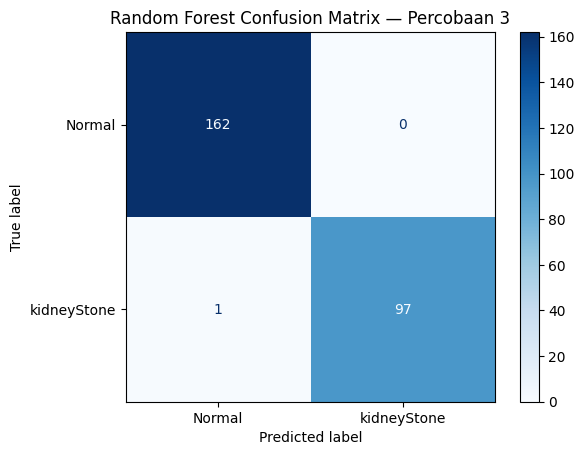

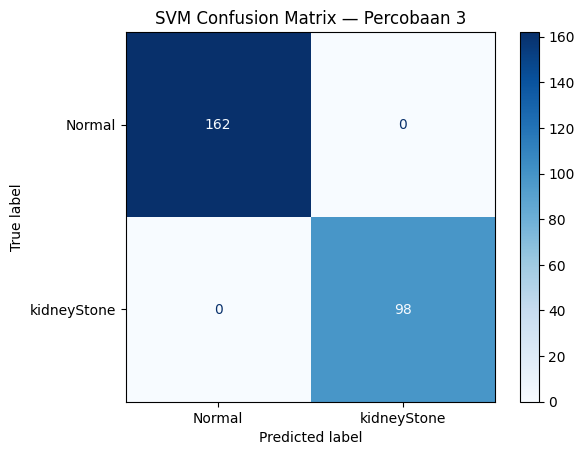

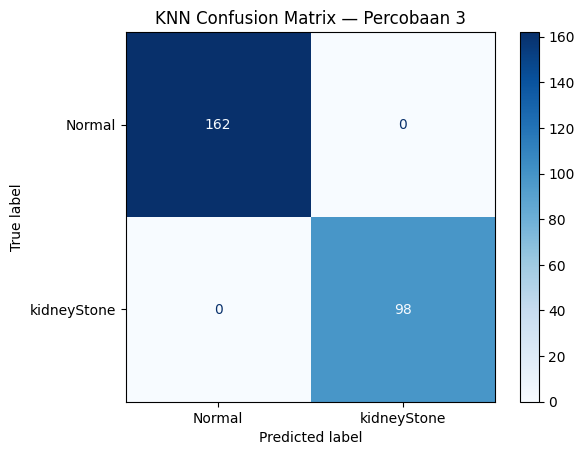

In [ ]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(np.unique(y_true)))
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

plot_confusion_matrix(y_test, y_pred_rf, 'Random Forest Confusion Matrix — Percobaan 3')
plot_confusion_matrix(y_test, y_pred_svm, 'SVM Confusion Matrix — Percobaan 3')
plot_confusion_matrix(y_test, y_pred_knn, 'KNN Confusion Matrix — Percobaan 3')

## Visualisasi Confusion Matrix

### Fungsi

Cell ini menampilkan Confusion Matrix untuk mengevaluasi hasil klasifikasi Random Forest (RF), Support Vector Machine (SVM), dan K-Nearest Neighbor (KNN) secara lebih rinci.

Confusion Matrix digunakan untuk mengetahui jumlah prediksi yang benar maupun salah pada setiap kelas sehingga dapat memberikan gambaran yang lebih lengkap mengenai performa model dibandingkan hanya menggunakan nilai akurasi.

### Analisis

Berdasarkan hasil Confusion Matrix, hampir seluruh data testing berhasil diklasifikasikan dengan benar oleh ketiga algoritma yang digunakan.

Hasil Confusion Matrix menunjukkan:

| Algoritma | TN | FP | FN | TP |
|------------|----|----|----|----|
| Random Forest | 162 | 0 | 1 | 97 |
| SVM | 162 | 0 | 0 | 98 |
| KNN | 162 | 0 | 0 | 98 |

Pada Random Forest terdapat 1 data False Negative yang menunjukkan bahwa satu citra Kidney Stone diprediksi sebagai kelas Normal. Akibatnya, nilai akurasi tidak mencapai 100%, meskipun tingkat kesalahan yang terjadi sangat kecil dibandingkan total 260 data testing yang digunakan.

Sementara itu, SVM dan KNN berhasil mengklasifikasikan seluruh data testing dengan benar sehingga tidak terdapat nilai False Positive maupun False Negative. Seluruh citra Normal dan Kidney Stone berhasil dikenali sesuai kelasnya masing-masing.

Tidak adanya nilai False Positive pada seluruh algoritma menunjukkan bahwa tidak terdapat citra Normal yang salah diprediksi sebagai Kidney Stone. Hal ini mengindikasikan bahwa karakteristik tekstur citra Normal relatif konsisten dan mudah dikenali oleh model.

Hasil ini menunjukkan bahwa preprocessing ketiga yang menggunakan CLAHE dan Sharpening mampu menghasilkan fitur tekstur yang sangat representatif untuk proses klasifikasi. CLAHE meningkatkan kontras lokal sehingga detail tekstur menjadi lebih jelas, sedangkan Sharpening mempertegas batas objek dan meningkatkan perbedaan intensitas antar piksel.

Menariknya, performa yang sangat tinggi tersebut diperoleh meskipun setelah proses seleksi fitur hanya tersisa 6 fitur dari total 28 fitur awal. Hal ini menunjukkan bahwa kombinasi CLAHE dan Sharpening berhasil menghasilkan fitur-fitur yang lebih informatif sehingga SVM dan KNN mampu mencapai akurasi 100% dengan jumlah fitur yang lebih sedikit dibandingkan preprocessing lainnya.

Secara keseluruhan, hasil Confusion Matrix menunjukkan bahwa preprocessing ketiga memberikan representasi tekstur yang sangat baik untuk proses klasifikasi. Dari ketiga algoritma yang diuji, SVM dan KNN menunjukkan performa terbaik karena mampu mengklasifikasikan seluruh data testing tanpa kesalahan, sedangkan Random Forest hanya mengalami satu kesalahan klasifikasi pada kelas Kidney Stone.

In [20]:
print('=== RINGKASAN HASIL PERCOBAAN 3 ===')
print(f'Preprocessing: Resize (256x256) + Grayscale + CLAHE + Sharpening')
print(f'Jumlah Fitur Setelah Seleksi: {X_train.shape[1]}')
print(f'\nAkurasi Testing Set:')
print(f'  Random Forest : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'  SVM           : {accuracy_score(y_test, y_pred_svm):.4f}')
print(f'  KNN           : {accuracy_score(y_test, y_pred_knn):.4f}')

=== RINGKASAN HASIL PERCOBAAN 3 ===
Preprocessing: Resize (256x256) + Grayscale + CLAHE + Sharpening
Jumlah Fitur Setelah Seleksi: 6

Akurasi Testing Set:
  Random Forest : 0.9962
  SVM           : 1.0000
  KNN           : 1.0000
